In [1]:
import pandas as pd
import sys
sys.path.append("../")

In [2]:
df = pd.read_csv(
    "../dataset/hdfc_loan_dataset_cleaned.csv"
)

df.head()

,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,...,Co-signer_Relationship,Monthly_Expense,Organization_Type,Region_Branch,Mobile_Verified,Email_Verified,Loan_to_Annual_Income,Customer_Sentiment,State,Occupation
0,Male,No,2,Graduate,Salaried,56976,0,8031545,360,1,...,Friend,30391,Public,KOL-004,No,Yes,11.747,Positive,Delhi,Farmer
1,Male,No,0,Graduate,Unemployed,1856,0,899361,240,1,...,Sibling,1856,Startup,DEL-001,No,Yes,40.381,Negative,Punjab,Civil Engineer
2,Female,Yes,0,Graduate,Salaried,64553,0,2387748,60,1,...,Unknown,24557,Private,BLR-003,Yes,Yes,3.082,Positive,Maharashtra,Medical Representative
3,Male,No,0,Graduate,Salaried,88450,0,658856,12,1,...,Friend,36750,Startup,KOL-004,Yes,Yes,0.621,Negative,Gujarat,Marketing Executive
4,Male,Yes,3,Graduate,Self-Employed,9539,0,198671,36,0,...,Parent,3920,Public,BLR-003,Yes,Yes,1.736,Neutral,West Bengal,Shopkeeper


In [3]:
df["High_Risk"] = (
    df["Default_History_Count"] > 0
).astype(int)

df["High_Risk"].value_counts()

High_Risk
0    906
1     94
Name: count, dtype: int64

In [4]:
df["High_Risk"].value_counts(
    normalize=True
) * 100

High_Risk
0    90.6
1     9.4
Name: proportion, dtype: float64

In [5]:
risk_features = [
    "Debt_to_Income_Ratio",
    "Existing_EMIs",
    "CIBIL_Score",
    "Employment_Length_Years",
    "Annual_Household_Income",
    "Loan_to_Annual_Income",
    "Loan_Amount",
    "Monthly_Expense",
    "Asset_Value",
    "Credit_History",
    "Applicant_Income",
    "Age",
    "Employment_Status",
    "Occupation",
    "Property_Area"
]

X = df[risk_features]

y = df["High_Risk"]

print(X.shape)
print(y.shape)

(1000, 15)
(1000,)


In [7]:
from src.preprocessing import (
    encode_features,
    split_data,
    scale_data
)

In [8]:
X = encode_features(X)
print(X.shape)

(1000, 34)


In [9]:
X_train, X_test, y_train, y_test = split_data(
    X,
    y
)

print(X_train.shape)
print(X_test.shape)

(800, 34)
(200, 34)


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print()

print("After SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
High_Risk
0    725
1     75
Name: count, dtype: int64

After SMOTE
High_Risk
0    725
1    725
Name: count, dtype: int64


In [12]:
X_train_scaled, X_test_scaled, scaler = scale_data(
    X_train_smote,
    X_test
)

In [13]:
from src.train import (
    train_logistic_regression,
    train_random_forest,
    train_xgboost
)

train.py loaded


In [14]:
logistic_model = train_logistic_regression(
    X_train_scaled,
    y_train_smote
)

random_forest_model = train_random_forest(
    X_train_smote,
    y_train_smote
)

xgboost_model = train_xgboost(
    X_train_smote,
    y_train_smote
)

print("All models trained successfully")

All models trained successfully


In [16]:
from src.evaluate import evaluate_model
logistic_results = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test
)

rf_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

xgb_results = evaluate_model(
    xgboost_model,
    X_test,
    y_test
)

In [17]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
})

comparison_df

,Logistic Regression,Random Forest,XGBoost
Accuracy,0.915000,0.915000,0.945000
Precision,0.600000,0.571429,0.722222
Recall,0.315789,0.421053,0.684211
F1,0.413793,0.484848,0.702703
ROC_AUC,0.646845,0.693952,0.828293


In [18]:
from src.train import tune_xgboost

In [19]:
xgb_grid = tune_xgboost(
    X_train_smote,
    y_train_smote
)

In [20]:
print("Best Parameters:")
print(xgb_grid.best_params_)

print()

print("Best Score:")
print(xgb_grid.best_score_)

Best Parameters:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}

Best Score:
0.9589189757218503


In [21]:
best_xgb_model = xgb_grid.best_estimator_

<Figure size 600x500 with 0 Axes>

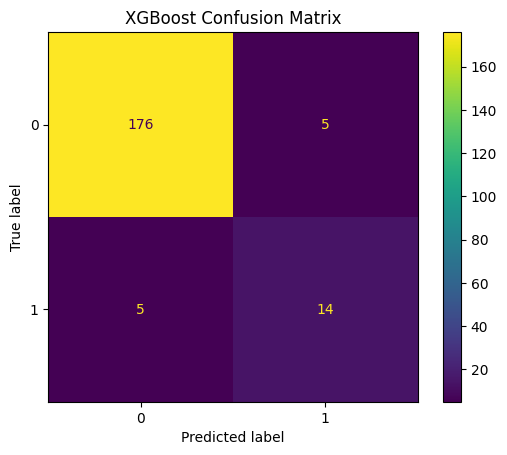

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(
    best_xgb_model,
    X_test,
    y_test
)

plt.title("XGBoost Confusion Matrix")

plt.savefig(
    "../visuals/default_risk_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

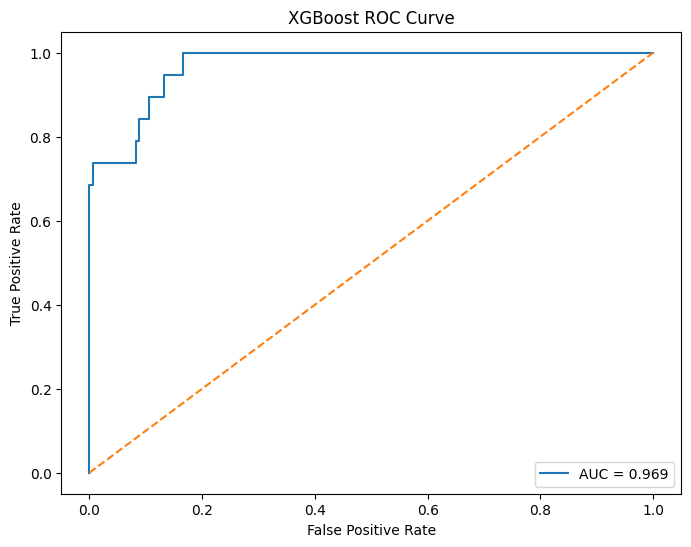

In [23]:
from sklearn.metrics import roc_curve, auc

y_prob = best_xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()

plt.savefig(
    "../visuals/default_risk_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
9,Credit_History,0.569027
18,Occupation_Delivery Partner,0.038560
14,Employment_Status_Unemployed,0.034898
13,Employment_Status_Self-Employed,0.028204
2,CIBIL_Score,0.025678
29,Occupation_Small Business Owner,0.024066
21,Occupation_Factory Worker,0.020676
28,Occupation_Shopkeeper,0.019444
12,Employment_Status_Salaried,0.018945
22,Occupation_Farmer,0.018330


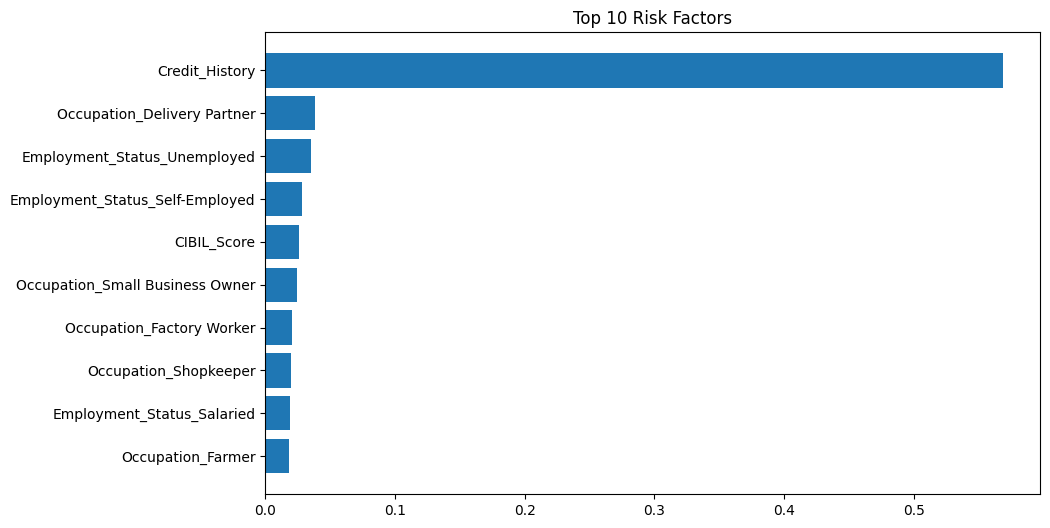

In [25]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Risk Factors")

plt.savefig(
    "../visuals/default_risk_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

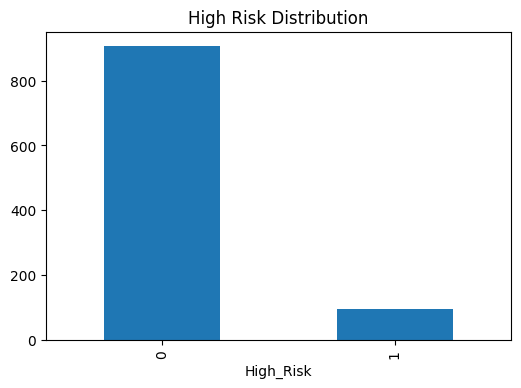

In [26]:
plt.figure(figsize=(6,4))

df["High_Risk"].value_counts().plot(
    kind="bar"
)

plt.title("High Risk Distribution")

plt.savefig(
    "../visuals/high_risk_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

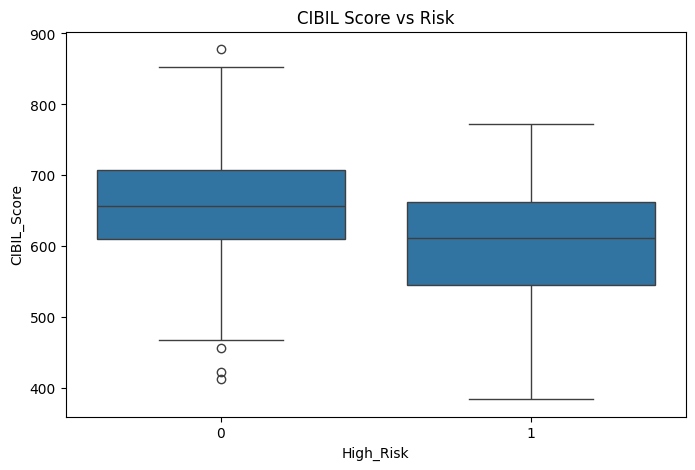

In [27]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="High_Risk",
    y="CIBIL_Score",
    data=df
)

plt.title("CIBIL Score vs Risk")

plt.savefig(
    "../visuals/cibil_vs_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

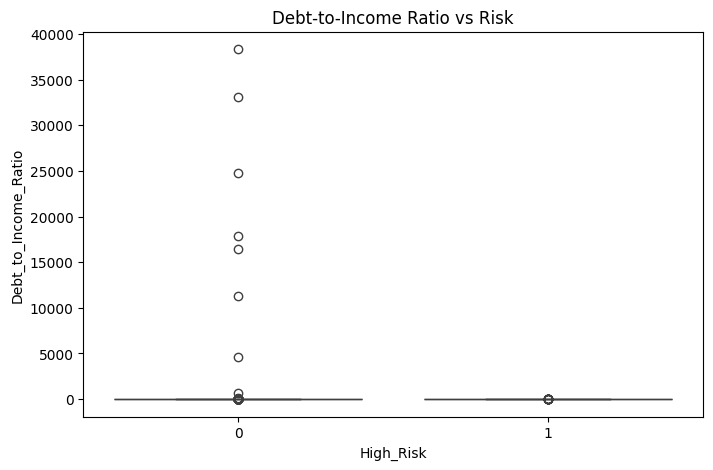

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="High_Risk",
    y="Debt_to_Income_Ratio",
    data=df
)

plt.title("Debt-to-Income Ratio vs Risk")

plt.savefig(
    "../visuals/dti_vs_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
import joblib

joblib.dump(
    best_xgb_model,
    "../models/default_risk_model.pkl"
)

print("Default Risk Model Saved")

Default Risk Model Saved
